In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.merge import merge
from scipy.ndimage import map_coordinates
from pyproj import Transformer

PROJECT = Path.cwd().parents[1]

CSV = PROJECT / "data" / "gravity" / "Onyx_Profile_Harmonica_LiDAR_Corrected.csv"

DEM_DIR = (
    PROJECT
    / "data"
    / "LiDAR"
    / "LiDAR_2026-06-05T19_40_33.076Z"
)

DEM_TILES = sorted(DEM_DIR.glob("*.tif"))

OUT_CSV = PROJECT / "data" / "gravity" / "Onyx_Profile_DEM_Elevation_Fixed.csv"
OUT_QC = PROJECT / "data" / "gravity" / "Onyx_DEM_Elevation_QC.csv"

DEM_Z_FACTOR = 0.30480060960121924

df = pd.read_csv(CSV)
df.columns = df.columns.str.strip()

print(f"Found {len(DEM_TILES)} LiDAR tiles")
print(df.columns.tolist())

Found 21 LiDAR tiles
['station', 'lat', 'lon', 'elev_m', 'grav_mean', 'grav_dc', 'grav_rel', 'FAC', 'FAA', 'instrument', 'n', 'grav_std', 'datetime_mid', 'easting', 'northing', 'station_m', 'elevation_m', 'gravity_tied_mgal', 'free_air_correction_mgal', 'reference_elevation_m', 'obs_height_used_m', 'harmonica_gz_mgal', 'gravity_free_air_only_mgal', 'harmonica_gz_relative_mgal', 'corrected_add_rel_mgal', 'corrected_subtract_rel_mgal', 'gravity_harmonica_lidar_corrected_mgal']


In [35]:
# megre DEM files and convert ft to m
srcs = [rasterio.open(p) for p in DEM_TILES]
merged, merged_transform = merge(srcs)

src_crs = srcs[0].crs
src_profile = srcs[0].profile.copy()
nodata = src_profile.get("nodata", None)

for src in srcs:
    src.close()

dem_src = merged[0].astype("float32")

if nodata is not None:
    dem_src = np.where(dem_src == nodata, np.nan, dem_src)

dem_src = dem_src * DEM_Z_FACTOR

print("DEM CRS:", src_crs)
print("DEM elevation range, meters:")
print(np.nanmin(dem_src), np.nanmax(dem_src))

DEM CRS: EPSG:6430
DEM elevation range, meters:
2018.1841 2508.4038


In [36]:
# Convert GPS coordinates into DEM CRS
to_dem_crs = Transformer.from_crs("EPSG:4326", src_crs, always_xy=True)

df["dem_x"], df["dem_y"] = to_dem_crs.transform(
    df["lon"].to_numpy(),
    df["lat"].to_numpy()
)

print("DEM x range:", df["dem_x"].min(), df["dem_x"].max())
print("DEM y range:", df["dem_y"].min(), df["dem_y"].max())

print("\nCoordinate differences:")
print(df.sort_values("station")[["station", "dem_x", "dem_y"]].to_string(index=False))

DEM x range: 2628468.5411631973 2628496.3566294103
DEM y range: 1420028.4139419803 1420101.6853477561

Coordinate differences:
 station        dem_x        dem_y
     1.0 2.628495e+06 1.420028e+06
     3.0 2.628495e+06 1.420028e+06
     4.0 2.628495e+06 1.420028e+06
     5.0 2.628495e+06 1.420028e+06
     6.0 2.628495e+06 1.420028e+06
     7.0 2.628495e+06 1.420028e+06
     8.0 2.628495e+06 1.420028e+06
     9.0 2.628495e+06 1.420028e+06
    10.0 2.628495e+06 1.420028e+06
    11.0 2.628496e+06 1.420065e+06
    12.0 2.628496e+06 1.420065e+06
    12.5 2.628496e+06 1.420065e+06
    13.0 2.628496e+06 1.420065e+06
    13.5 2.628496e+06 1.420065e+06
    14.0 2.628496e+06 1.420065e+06
    14.5 2.628496e+06 1.420065e+06
    15.0 2.628496e+06 1.420065e+06
    15.0 2.628496e+06 1.420065e+06
    15.5 2.628496e+06 1.420065e+06
    17.0 2.628496e+06 1.420065e+06
    18.0 2.628496e+06 1.420065e+06
    19.0 2.628496e+06 1.420065e+06
    20.0 2.628496e+06 1.420065e+06
    21.0 2.628496e+06 1.420065e+0

In [37]:
# diagnose repeated coordinates
d = df.sort_values("station").copy()

print("DEM x differences:")
print(np.diff(d["dem_x"]))

print("\nDEM y differences:")
print(np.diff(d["dem_y"]))

DEM x differences:
[  0.           0.           0.           0.           0.
   0.           0.           0.           0.54864374   0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.54864375   0.
   0.           0.           0.           0.           0.
 -27.81546621]

DEM y differences:
[ 0.          0.          0.          0.          0.          0.
  0.          0.         36.42621937  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         36.42622025
  0.          0.          0.          0.          0.          0.
  0.41896615]


In [38]:
# reconstruct stationcoords along grav line
s = df["station"].astype(float)

start = df.loc[df["station"].idxmin()]
end = df.loc[df["station"].idxmax()]

x0, y0 = start["dem_x"], start["dem_y"]
x1, y1 = end["dem_x"], end["dem_y"]

s0, s1 = s.min(), s.max()

df["dem_x_fixed_line"] = x0 + (s - s0) / (s1 - s0) * (x1 - x0)
df["dem_y_fixed_line"] = y0 + (s - s0) / (s1 - s0) * (y1 - y0)

print(
    df[
        ["station", "dem_x", "dem_y", "dem_x_fixed_line", "dem_y_fixed_line"]
    ].to_string(index=False)
)

 station        dem_x        dem_y  dem_x_fixed_line  dem_y_fixed_line
     1.0 2.628495e+06 1.420028e+06      2.628495e+06      1.420028e+06
     3.0 2.628495e+06 1.420028e+06      2.628493e+06      1.420034e+06
     4.0 2.628495e+06 1.420028e+06      2.628492e+06      1.420036e+06
     5.0 2.628495e+06 1.420028e+06      2.628491e+06      1.420039e+06
     6.0 2.628495e+06 1.420028e+06      2.628490e+06      1.420041e+06
     7.0 2.628495e+06 1.420028e+06      2.628490e+06      1.420044e+06
     8.0 2.628495e+06 1.420028e+06      2.628489e+06      1.420047e+06
     9.0 2.628495e+06 1.420028e+06      2.628488e+06      1.420049e+06
    10.0 2.628495e+06 1.420028e+06      2.628487e+06      1.420052e+06
    11.0 2.628496e+06 1.420065e+06      2.628486e+06      1.420055e+06
    12.0 2.628496e+06 1.420065e+06      2.628485e+06      1.420057e+06
    12.5 2.628496e+06 1.420065e+06      2.628484e+06      1.420059e+06
    13.0 2.628496e+06 1.420065e+06      2.628484e+06      1.420060e+06
    13

In [39]:
# Bilinear sample DEM using accurate station positions
inv_transform = ~merged_transform

cols = []
rows = []

for x, y in zip(df["dem_x_fixed_line"], df["dem_y_fixed_line"]):
    col, row = inv_transform * (x, y)
    cols.append(col)
    rows.append(row)

rows = np.array(rows)
cols = np.array(cols)

df["dem_elevation_m_raw_fixed_line"] = map_coordinates(
    dem_src,
    [rows, cols],
    order=1,
    mode="nearest"
)

print(
    df[
        ["station", "elev_m", "dem_elevation_m_raw_fixed_line"]
    ].to_string(index=False)
)

 station   elev_m  dem_elevation_m_raw_fixed_line
     1.0 2112.468                     2124.109375
     3.0 2111.569                     2124.038818
     4.0 2111.692                     2123.997803
     5.0 2111.862                     2123.943848
     6.0 2111.790                     2123.899658
     7.0 2111.286                     2123.836914
     8.0 2111.152                     2123.807861
     9.0 2111.213                     2123.825684
    10.0 2111.151                     2123.818115
    11.0 2111.017                     2123.739746
    12.0 2110.432                     2123.660645
    12.5 2110.407                     2123.621338
    13.0 2110.634                     2123.555908
    13.5 2110.257                     2123.480713
    14.0 2111.519                     2123.430176
    14.5 2111.614                     2123.387207
    15.0 2111.399                     2123.351074
    15.0 2111.399                     2123.351074
    15.5 2111.149                     2123.314209


In [41]:
# vertically align DEM to GPS datum
elev_qc = (
    df[["station", "elev_m", "dem_elevation_m_raw_fixed_line"]]
    .groupby("station", as_index=False)
    .mean()
    .sort_values("station")
)

vertical_shift_m = np.nanmedian(
    elev_qc["elev_m"] - elev_qc["dem_elevation_m_raw_fixed_line"]
)

print("Median vertical shift:", vertical_shift_m, "m")

elev_qc["dem_elevation_m_fixed"] = (
    elev_qc["dem_elevation_m_raw_fixed_line"] + vertical_shift_m
)

elev_qc["gps_minus_dem_fixed_m"] = (
    elev_qc["elev_m"] - elev_qc["dem_elevation_m_fixed"]
)

print(elev_qc.to_string(index=False))

Median vertical shift: -12.563298828124971 m
 station   elev_m  dem_elevation_m_raw_fixed_line  dem_elevation_m_fixed  gps_minus_dem_fixed_m
     1.0 2112.468                     2124.109375            2111.546143               0.921857
     3.0 2111.569                     2124.038818            2111.475586               0.093414
     4.0 2111.692                     2123.997803            2111.434570               0.257430
     5.0 2111.862                     2123.943848            2111.380615               0.481385
     6.0 2111.790                     2123.899658            2111.336426               0.453574
     7.0 2111.286                     2123.836914            2111.273682               0.012318
     8.0 2111.152                     2123.807861            2111.244629              -0.092629
     9.0 2111.213                     2123.825684            2111.262451              -0.049451
    10.0 2111.151                     2123.818115            2111.254883              -0.10

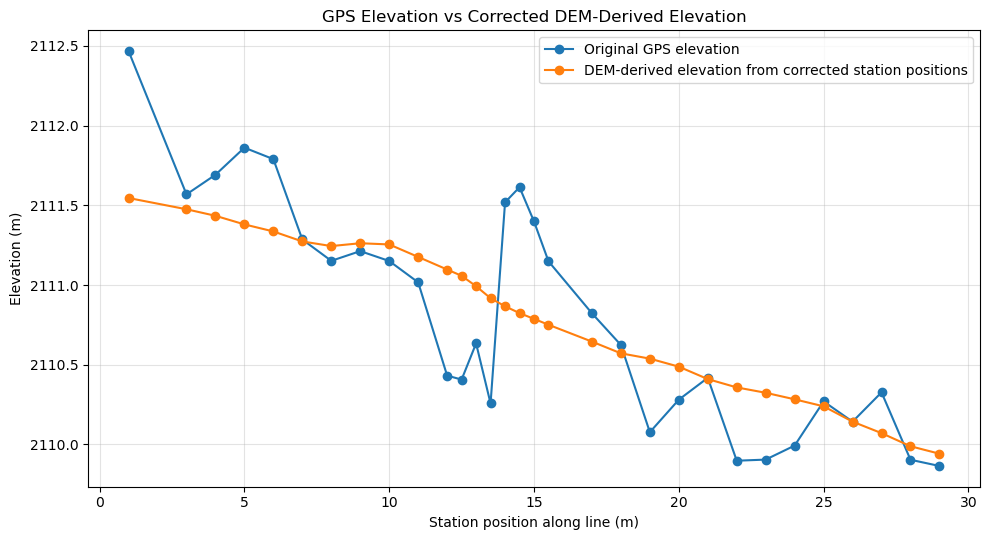

In [42]:
# plot GPS vs fixed DEM elevations
plt.figure(figsize=(10, 5.5))

plt.plot(
    elev_qc["station"],
    elev_qc["elev_m"],
    "o-",
    label="Original GPS elevation"
)

plt.plot(
    elev_qc["station"],
    elev_qc["dem_elevation_m_fixed"],
    "o-",
    label="DEM-derived elevation from corrected station positions"
)

plt.xlabel("Station position along line (m)")
plt.ylabel("Elevation (m)")
plt.title("GPS Elevation vs Corrected DEM-Derived Elevation")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

In [43]:
# replace elevations and recompute corrections
df = df.drop(
    columns=[
        "dem_elevation_m_fixed",
        "gps_minus_dem_fixed_m",
        "elevation_m_original",
        "elevation_m_fixed_dem",
    ],
    errors="ignore"
)

df = df.merge(
    elev_qc[["station", "dem_elevation_m_fixed", "gps_minus_dem_fixed_m"]],
    on="station",
    how="left"
)

df["elevation_m_original"] = df["elev_m"]
df["elevation_m_fixed_dem"] = df["dem_elevation_m_fixed"]

df["elev_m"] = df["elevation_m_fixed_dem"]

density_kg_m3 = 2670
rho_g_cm3 = density_kg_m3 / 1000

reference_elevation = df["elev_m"].min()

df["reference_elevation_m"] = reference_elevation
df["height_above_reference_m"] = df["elev_m"] - reference_elevation

df["FAC"] = 0.3086 * df["height_above_reference_m"]
df["bouguer_correction_mgal"] = 0.04193 * rho_g_cm3 * df["height_above_reference_m"]

df["gravity_free_air_only_mgal"] = df["grav_rel"] + df["FAC"]

df["gravity_simple_bouguer_corrected_mgal"] = (
    df["grav_rel"]
    + df["FAC"]
    - df["bouguer_correction_mgal"]
)

df["gravity_harmonica_lidar_corrected_mgal"] = (
    df["gravity_free_air_only_mgal"]
    - df["harmonica_gz_relative_mgal"]
)

df["corrected_subtract_rel_mgal"] = df["gravity_harmonica_lidar_corrected_mgal"]

print("Reference elevation used:", reference_elevation)

Reference elevation used: 2109.942


In [45]:
df_export = df.copy()

df_export["elev_m_original"] = df_export["elev_m"]
df_export["elev_m"] = df_export["dem_elevation_m_fixed"]
df_export["elevation_m_fixed_dem"] = df_export["dem_elevation_m_fixed"]

df

,station,lat,lon,elev_m,grav_mean,grav_dc,grav_rel,FAC,FAA,instrument,...,dem_x_fixed_line,dem_y_fixed_line,dem_elevation_m_raw_fixed_line,dem_elevation_m_fixed,gps_minus_dem_fixed_m,elevation_m_original,elevation_m_fixed_dem,height_above_reference_m,bouguer_correction_mgal,gravity_simple_bouguer_corrected_mgal
0,1.0,40.4787,-106.8355,2111.546143,3891.8183,3891.8184,0.0162,0.495071,651.9238,41422,...,2.628495e+06,1.420028e+06,2124.109375,2111.546143,0.921857,2112.468,2111.546143,1.604248,0.179601,0.331670
1,3.0,40.4787,-106.8355,2111.475586,3891.8427,3891.8428,0.0406,0.473297,651.6708,41422,...,2.628493e+06,1.420034e+06,2124.038818,2111.475586,0.093414,2111.569,2111.475586,1.533691,0.171702,0.342196
2,4.0,40.4787,-106.8355,2111.434570,3891.8650,3891.8652,0.0630,0.460640,651.7311,41422,...,2.628492e+06,1.420036e+06,2123.997803,2111.434570,0.257430,2111.692,2111.434570,1.492676,0.167110,0.356530
3,5.0,40.4787,-106.8355,2111.380615,3891.8853,3891.8855,0.0833,0.443989,651.8040,41422,...,2.628491e+06,1.420039e+06,2123.943848,2111.380615,0.481385,2111.862,2111.380615,1.438721,0.161069,0.366220
4,6.0,40.4787,-106.8355,2111.336426,3891.8993,3891.8996,0.0974,0.430352,651.7958,41422,...,2.628490e+06,1.420041e+06,2123.899658,2111.336426,0.453574,2111.790,2111.336426,1.394531,0.156122,0.371630
5,7.0,40.4787,-106.8355,2111.273682,3891.9140,3891.9143,0.1121,0.410990,651.6549,41422,...,2.628490e+06,1.420044e+06,2123.836914,2111.273682,0.012318,2111.286,2111.273682,1.331787,0.149098,0.373992
6,8.0,40.4787,-106.8355,2111.244629,3891.9357,3891.9360,0.1338,0.402024,651.6353,41422,...,2.628489e+06,1.420047e+06,2123.807861,2111.244629,-0.092629,2111.152,2111.244629,1.302734,0.145845,0.389979
7,9.0,40.4787,-106.8355,2111.262451,3891.9553,3891.9557,0.1535,0.407524,651.6738,41422,...,2.628488e+06,1.420049e+06,2123.825684,2111.262451,-0.049451,2111.213,2111.262451,1.320557,0.147840,0.413183
8,10.0,40.4787,-106.8355,2111.254883,3891.9743,3891.9747,0.1725,0.405188,651.6737,41422,...,2.628487e+06,1.420052e+06,2123.818115,2111.254883,-0.103883,2111.151,2111.254883,1.312988,0.146993,0.430695
9,11.0,40.4788,-106.8355,2111.176514,3891.9880,3891.9884,0.1862,0.381003,651.6460,41422,...,2.628486e+06,1.420055e+06,2123.739746,2111.176514,-0.159514,2111.017,2111.176514,1.234619,0.138219,0.428984


In [46]:
OUT_FIXED_ELEV = PROJECT / "data" / "gravity" / "Onyx_Profile_DEM_Elevations_ONLY.csv"

df_export.to_csv(OUT_FIXED_ELEV, index=False)

print("Saved fixed-elevation CSV:")
print(OUT_FIXED_ELEV)

Saved fixed-elevation CSV:
/Users/tessamurphy/work/classes/GPGN486/Geophysical-Characterization-of-the-Historic-Onyx-Mine-in-Steamboat-Springs-CO.-/data/gravity/Onyx_Profile_DEM_Elevations_ONLY.csv
